In [1]:
import math

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
DEVICE = torch.device("mps")

## RNN

In [21]:
class MyRNN(nn.Module):

    def __init__(self, input_size: int, hidden_size: int, batch_first: bool):
        super().__init__()

        self.hidden_size = hidden_size

        # params
        self.w_ih = nn.Parameter(torch.empty(input_size, hidden_size))
        self.w_hh = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b_ih = nn.Parameter(torch.empty(1, hidden_size))
        self.b_hh = nn.Parameter(torch.empty(1, hidden_size))

        self._init_params()

    def _init_params(self):
        # from the 2015 delving deep paper...
        # but with 1 (not 2) as numerator
        # as we will use tanh, not relu
        a = 1 / math.sqrt(self.hidden_size)

        # old, kaiming
        # nn.init.kaiming_normal_(self.w_ih, a)
        # nn.init.kaiming_normal_(self.w_hh, a)
        # nn.init.kaiming_normal_(self.b_ih, a)
        # nn.init.kaiming_normal_(self.b_hh, a)

        # new, match pytorch
        nn.init.uniform_(self.w_ih, -a, a)
        nn.init.uniform_(self.w_hh, -a, a)
        nn.init.uniform_(self.b_ih, -a, a)
        nn.init.uniform_(self.b_hh, -a, a)

    def forward(self, x: torch.Tensor, h_0: torch.Tensor = None) -> tuple:
        if x.dim() == 2:  # assume missing batch
            x = x.unsqueeze(0)  # add batch
        # (B, T, C)
        batch_size, seq_len, _ = x.size()

        if h_0 is None:
            h_0 = torch.zeros(
                batch_size, self.hidden_size, device=x.device, dtype=x.dtype
            )

        out = []
        h_t = h_0
        for t in range(seq_len):
            x_t = x[:, t, :]

            ih_mat = x_t @ self.w_ih + self.b_ih
            hh_mat = h_t @ self.w_hh + self.b_hh

            h_t = torch.tanh(ih_mat + hh_mat)
            out.append(h_t.unsqueeze(1))

        out = torch.concat(out, dim=1)
        return out, h_t

### Let's try the adding problem

In [4]:
BATCH_SIZE=64
T=20

In [5]:
class SumDataset(Dataset):
    def __init__(self, epoch_size: int = 10_000, T: int = 10):
        self.epoch_size = epoch_size
        self.T = T
    
    def _generate_one(self):
        x = torch.randint(0, 2, size=(self.T, 1), dtype=torch.float32)
        y = torch.cumsum(x, 0)
        return (x, y)
        
    def __getitem__(self, _) -> torch.Tensor:
        return self._generate_one()
    
    def __len__(self):
        return self.epoch_size

ds_train = SumDataset(10_000, T)
ds_test = SumDataset(1_000, T)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

In [6]:


def train(model, dl, epochs=10, lr=1e-3):
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.MSELoss()

    pbar = tqdm(range(epochs))
    losses = []
    model.train()
    for _ in pbar:
        avg_loss = 0
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
        
            optim.zero_grad()
            y_pred = model.forward(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()
            
            avg_loss += loss * x.size(0)
        avg_loss /= len(dl.dataset)
        pbar.set_postfix({"avg_loss": avg_loss.item()})
        losses.append(avg_loss.detach().cpu())

    plt.plot(losses)

def get_test_loss(model, dl_test):
    
    loss_fn = nn.MSELoss()
    model.eval()
    total_loss = 0
    for x, y in dl_test:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        
        y_pred = model.forward(x)
        loss = loss_fn(y_pred, y)
        total_loss += loss * x.size(0)
    return total_loss / len(dl_test.dataset)

def pretty_eval(model, ds_cls, T: int = 10):
    fig, axs = plt.subplots(4, 4)
    axs = axs.flatten()
    fig.set_size_inches(10, 10)
    ds = ds_cls(16, T=T)
    model.eval()
    for i in range(16):
        x, y = ds[i]
        x = x.to(DEVICE)
        y_pred = model.forward(x)
        
        ax = axs[i]
        ax.plot(y, label='Actual')
        ax.plot(y_pred.detach().cpu().squeeze(), label='Predicted')
    
    ax.legend() # just one :)
    plt.show()
        

In [7]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        # expect (B, T, 1)
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, h_t = self.rnn(x) # h_t not needed
        return self.fc(out)
        
class MyRNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        # expect (B, T, 1)
        self.rnn = MyRNN(
            input_size=1,
            hidden_size=16,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, h_t = self.rnn(x) # h_t not needed
        return self.fc(out)
        

100%|██████████| 100/100 [01:16<00:00,  1.31it/s, avg_loss=0.00187]

test loss: 0.0017093503847718239


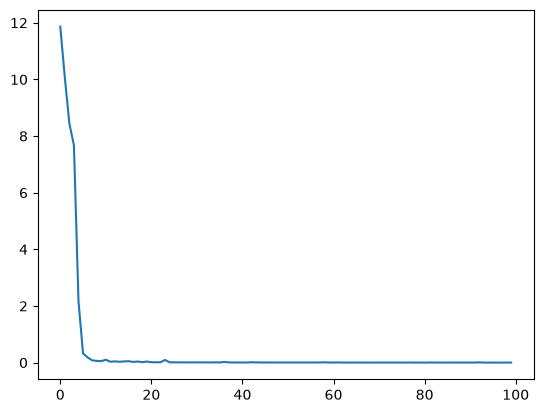

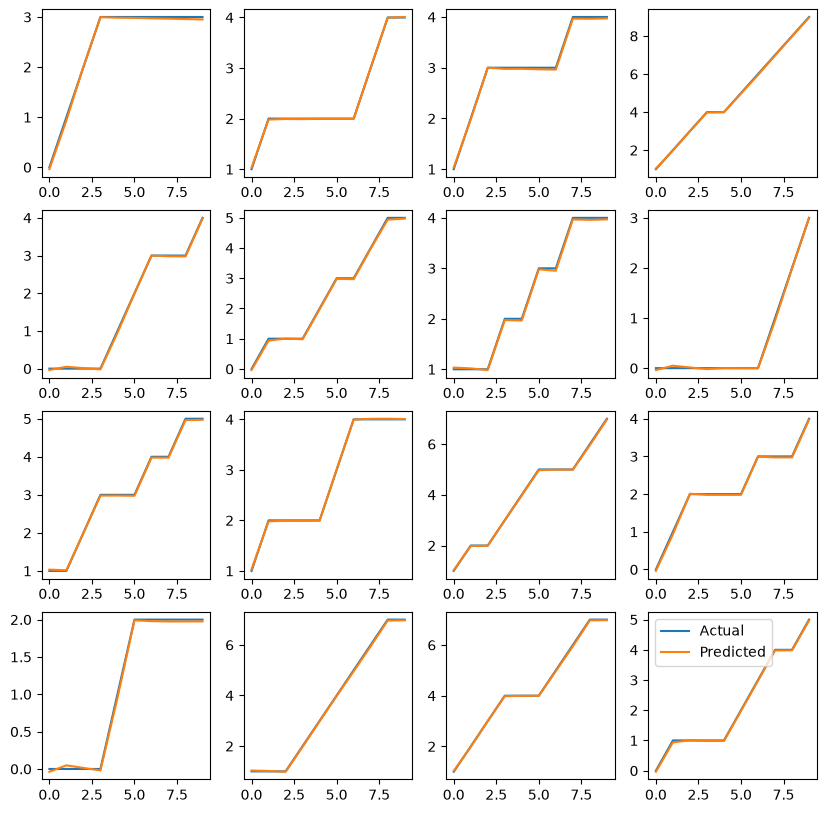

In [8]:
# Baseline
model = RNNModel().to(DEVICE)

train(model, dl_train, 100)
test_loss = get_test_loss(model, dl_test)
print(f'test loss: {test_loss.item()}')
pretty_eval(model, SumDataset)


100%|██████████| 100/100 [01:20<00:00,  1.24it/s, avg_loss=0.00213]

test loss: 0.0018729401053860784


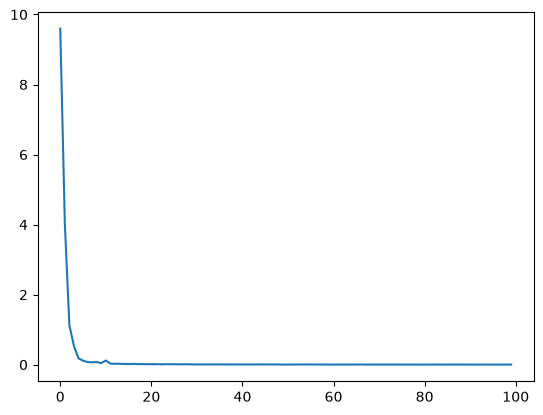

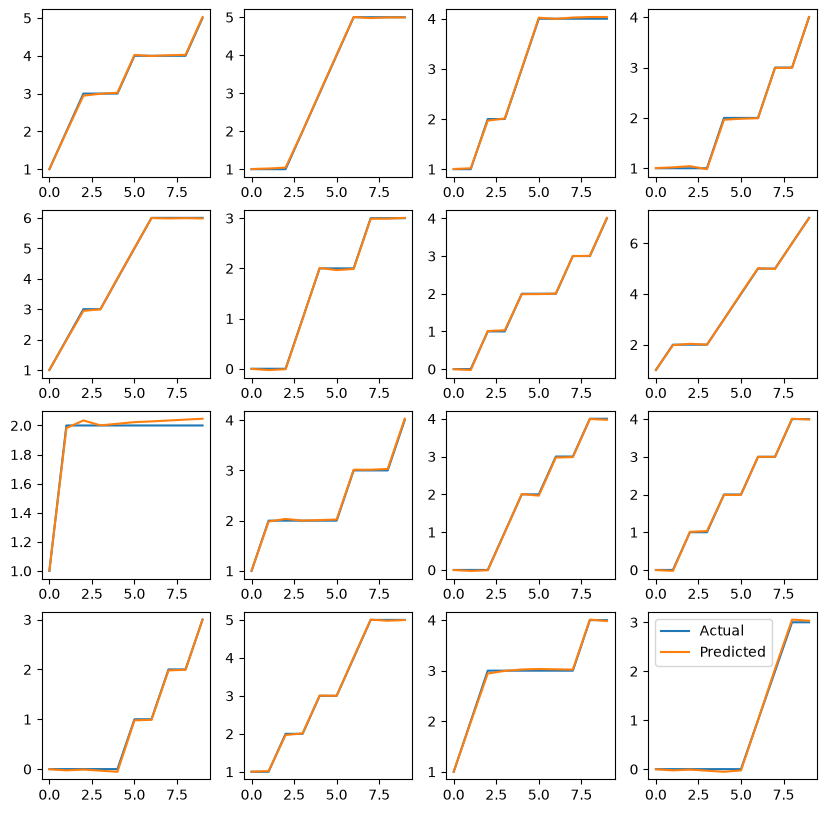

In [9]:
my_model = MyRNNModel().to(DEVICE)

train(my_model, dl_train, 100)
test_loss = get_test_loss(my_model, dl_test)
print(f'test loss: {test_loss.item()}')
pretty_eval(my_model, SumDataset)

In [ ]:
# this should be about the same at ~1
torch.linalg.matrix_norm(MyRNN(1, 16, True).w_hh, 2), torch.linalg.matrix_norm(nn.RNN(1, 16, batch_first=True).weight_hh_l0, 2) 

(tensor(1.0953, grad_fn=<AmaxBackward0>),
 tensor(1.0027, grad_fn=<AmaxBackward0>))